# Face Detection Project

## 1 Initialization

### 1.1 Collect Images using OpenCV

In [26]:
import os
import pandas
import matplotlib
import time
import uuid
import cv2

In [27]:
IMAGE_PATH = os.path.join('data','images')
number_images = 30

In [28]:
# import cv2

# for i in range(5):
#     cap = cv2.VideoCapture(i, cv2.CAP_DSHOW)
#     ret, frame = cap.read()
#     print(f"Index {i}: {ret}")
#     cap.release()

In [29]:
cap = cv2.VideoCapture(2, cv2.CAP_DSHOW)  
for _ in range(5):
    cap.read()

for imgnum in range(number_images):
    print('Collecting images {}'.format(imgnum))
    ret,frame = cap.read()

    if not ret or frame is None:
        print(f"Frame {imgnum} empty, skipping...")
        continue

    imgname = os.path.join(IMAGE_PATH,f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname,frame)
    cv2.imshow('frame',frame)
    time.sleep(0.5)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

### 1.2 Annotate Images with LabelMe


In [30]:
# !labelme

## 2 Review Dataset and Build Image Loading Function

### 2.1 import tensorflow and key dependenecies

In [31]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt

### 2.2 Limit GPU Memory Growth

In [32]:
# Avoid OOM errors by setting GPU Memory Consuption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)
    

In [33]:
tf.test.is_gpu_available()

False

In [34]:
tf.config.list_physical_devices('GPU')

[]

### 2.3 Load Images into TF Data Pipeline

In [35]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg',shuffle=False)

In [36]:
images.as_numpy_iterator().next()

b'data\\images\\4c95d0fc-7388-11f1-82d8-26b2b98917c5.jpg'

In [37]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [38]:
images = images.map(load_image)

In [39]:
images.as_numpy_iterator().next()

array([[[196, 189, 173],
        [195, 188, 172],
        [196, 189, 173],
        ...,
        [160, 145, 126],
        [160, 145, 126],
        [160, 145, 126]],

       [[195, 188, 172],
        [195, 188, 172],
        [195, 188, 172],
        ...,
        [159, 144, 125],
        [159, 144, 125],
        [159, 144, 125]],

       [[196, 189, 173],
        [195, 188, 172],
        [196, 189, 173],
        ...,
        [160, 145, 126],
        [160, 145, 126],
        [160, 145, 126]],

       ...,

       [[148, 136, 110],
        [147, 135, 109],
        [147, 135, 109],
        ...,
        [ 70,  55,  34],
        [ 70,  55,  34],
        [ 69,  54,  33]],

       [[147, 135, 109],
        [146, 134, 108],
        [146, 134, 108],
        ...,
        [ 69,  54,  35],
        [ 68,  53,  34],
        [ 68,  53,  34]],

       [[146, 134, 108],
        [146, 134, 108],
        [146, 134, 108],
        ...,
        [ 67,  52,  33],
        [ 67,  52,  33],
        [ 66,  51,  32]]

In [40]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

### 2.4 View Raw Imaes with Matplotlib

In [41]:
image_generator = images.batch(10).as_numpy_iterator()

In [42]:
plot_images = image_generator.next()


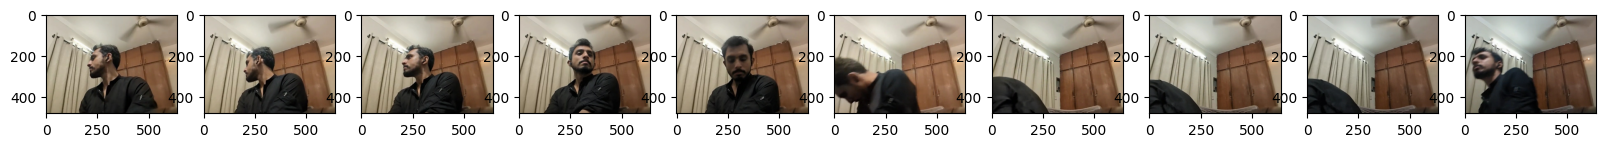

In [43]:
fig , ax = plt.subplots(ncols=10, figsize=(20,20))
for idx , image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

## 3 Partition Unagumented Data

### 3.1  Split data into train test and validation set

In [44]:
import os
import shutil
import random

In [45]:


# Paths
images_path = 'data/images'
labels_path = 'data/labels'

# Images list (.jpg files only)
images = [f for f in os.listdir(images_path) if f.endswith('.jpg')]
random.shuffle(images)  # randomly shuffle

# Split — 70% train, 20% test, 10% val
total = len(images)
train_end = int(total * 0.7)
test_end = int(total * 0.9)

train_imgs = images[:train_end]
test_imgs = images[train_end:test_end]
val_imgs = images[test_end:]

print(f"Total: {total}")
print(f"Train: {len(train_imgs)}")
print(f"Test: {len(test_imgs)}")
print(f"Val: {len(val_imgs)}")

# Copy function — image and label copied together
def copy_files(img_list, split):
    for img in img_list:
        # Image copy 
        shutil.copy(
            os.path.join(images_path, img),
            os.path.join('data', split, 'images', img)
        )
        # Label copy (same name, .json extension)
        label = img.replace('.jpg', '.json')
        label_src = os.path.join(labels_path, label)
        if os.path.exists(label_src):
            shutil.copy(
                label_src,
                os.path.join('data', split, 'labels', label)
            )

copy_files(train_imgs, 'train')
copy_files(test_imgs, 'test')
copy_files(val_imgs, 'val')

print("Split complete! ✅")

Total: 120
Train: 84
Test: 24
Val: 12
Split complete! ✅


## 4 Apply Image Augmentation on Images and Lables using Albumentation

### 4.1 Set Albumentations Transform Pipeline 

In [46]:
img = cv2.imread(os.path.join('data','train','images','4d3028b7-7388-11f1-8fb5-26b2b98917c5.jpg'))
img

array([[[179, 194, 203],
        [179, 194, 203],
        [179, 194, 203],
        ...,
        [126, 141, 160],
        [126, 141, 160],
        [126, 141, 160]],

       [[179, 194, 203],
        [179, 194, 203],
        [179, 194, 203],
        ...,
        [125, 140, 159],
        [125, 140, 159],
        [126, 141, 160]],

       [[179, 194, 203],
        [179, 194, 203],
        [179, 194, 203],
        ...,
        [126, 141, 160],
        [126, 141, 160],
        [126, 141, 160]],

       ...,

       [[106, 133, 147],
        [105, 132, 146],
        [104, 131, 145],
        ...,
        [ 40,  56,  68],
        [ 40,  56,  68],
        [ 40,  56,  68]],

       [[107, 134, 148],
        [106, 133, 147],
        [105, 132, 146],
        ...,
        [ 40,  56,  68],
        [ 40,  56,  68],
        [ 40,  56,  68]],

       [[106, 133, 147],
        [105, 132, 146],
        [104, 131, 145],
        ...,
        [ 40,  56,  68],
        [ 40,  56,  68],
        [ 40,  56,  68]]

In [47]:
img.shape

(480, 640, 3)

In [48]:
import albumentations as alb


In [49]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height=450),
                        alb.HorizontalFlip(p=0.5),
                        alb.RandomBrightnessContrast(p=0.2), 
                        alb.RandomGamma(p=0.2),
                        alb.RGBShift(p=0.2),
                        alb.VerticalFlip(p=0.5)],
                        bbox_params=alb.BboxParams(format='albumentations',
                                                   label_fields=['class_labels']))

### 4.2 Load a Test Image and Annotation with OpenCV and JSON

In [50]:
img = cv2.imread(os.path.join('data','train','images','ed64109c-7389-11f1-8846-26b2b98917c5.jpg'))
img

array([[[173, 188, 197],
        [173, 188, 197],
        [173, 188, 197],
        ...,
        [120, 135, 154],
        [120, 135, 154],
        [120, 135, 154]],

       [[173, 188, 197],
        [173, 188, 197],
        [173, 188, 197],
        ...,
        [120, 135, 154],
        [120, 135, 154],
        [120, 135, 154]],

       [[173, 188, 197],
        [173, 188, 197],
        [173, 188, 197],
        ...,
        [120, 135, 154],
        [120, 135, 154],
        [120, 135, 154]],

       ...,

       [[115, 140, 156],
        [117, 142, 158],
        [117, 142, 158],
        ...,
        [100, 124, 148],
        [102, 126, 150],
        [106, 130, 154]],

       [[114, 139, 155],
        [116, 141, 157],
        [117, 142, 158],
        ...,
        [ 92, 116, 140],
        [ 93, 117, 141],
        [ 96, 120, 144]],

       [[114, 139, 155],
        [116, 141, 157],
        [117, 142, 158],
        ...,
        [ 93, 117, 141],
        [ 93, 117, 141],
        [ 96, 120, 144]]

In [51]:
with open(os.path.join('data','train','labels','ed64109c-7389-11f1-8846-26b2b98917c5.json'), 'r') as f:
    label = json.load(f)

In [52]:
label['shapes'][0]['points']

[[162.44186046511626, 44.06976744186048],
 [441.51162790697674, 354.5348837209302]]

### 4.3 Extract Coordinates and Rescale to Match Image Resolution

In [53]:
coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]
coords

[162.44186046511626, 44.06976744186048, 441.51162790697674, 354.5348837209302]

In [54]:
coords = list(np.divide(coords, [640, 480, 640, 480]))
coords

[np.float64(0.25381540697674415),
 np.float64(0.091812015503876),
 np.float64(0.6898619186046512),
 np.float64(0.7386143410852714)]

### 4.4 Apply Augmentations and view Results

In [55]:
augmented = augmentor(image = img, bboxes=[coords],class_labels = ['Face'])
print(type(augmented))
print(augmented.keys())
print(augmented)


<class 'dict'>
dict_keys(['image', 'bboxes', 'class_labels'])
{'image': array([[[245, 255, 255],
        [245, 255, 255],
        [245, 255, 255],
        ...,
        [219, 231, 253],
        [217, 229, 250],
        [217, 229, 250]],

       [[244, 255, 255],
        [244, 255, 255],
        [245, 255, 255],
        ...,
        [215, 226, 248],
        [213, 225, 247],
        [212, 224, 245]],

       [[244, 255, 255],
        [244, 255, 255],
        [244, 255, 255],
        ...,
        [210, 222, 243],
        [209, 221, 242],
        [209, 221, 242]],

       ...,

       [[119, 142, 163],
        [157, 180, 200],
        [190, 213, 234],
        ...,
        [ 60,  60,  67],
        [ 58,  58,  65],
        [ 60,  60,  67]],

       [[125, 148, 168],
        [161, 185, 205],
        [192, 216, 236],
        ...,
        [ 58,  58,  65],
        [ 58,  58,  65],
        [ 58,  58,  65]],

       [[133, 157, 177],
        [168, 192, 212],
        [196, 219, 240],
        ...,
  

In [56]:
print(augmented['image'])
print(augmented['image'].shape)

[[[245 255 255]
  [245 255 255]
  [245 255 255]
  ...
  [219 231 253]
  [217 229 250]
  [217 229 250]]

 [[244 255 255]
  [244 255 255]
  [245 255 255]
  ...
  [215 226 248]
  [213 225 247]
  [212 224 245]]

 [[244 255 255]
  [244 255 255]
  [244 255 255]
  ...
  [210 222 243]
  [209 221 242]
  [209 221 242]]

 ...

 [[119 142 163]
  [157 180 200]
  [190 213 234]
  ...
  [ 60  60  67]
  [ 58  58  65]
  [ 60  60  67]]

 [[125 148 168]
  [161 185 205]
  [192 216 236]
  ...
  [ 58  58  65]
  [ 58  58  65]
  [ 58  58  65]]

 [[133 157 177]
  [168 192 212]
  [196 219 240]
  ...
  [ 58  58  65]
  [ 58  58  65]
  [ 58  58  65]]]
(450, 450, 3)


In [57]:
augmented['bboxes']

[[0.17875969780815973,
  0.07126614888509114,
  0.7989146931966146,
  0.7611886088053386]]

In [58]:
augmented['class_labels']

['Face']

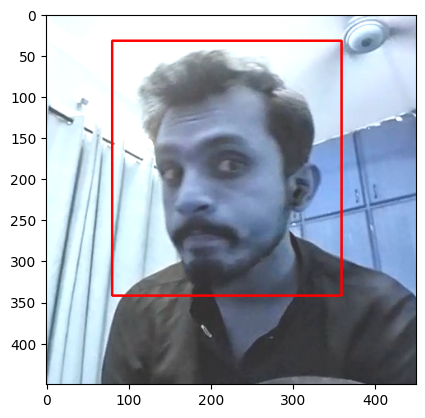

In [59]:
cv2.rectangle(augmented['image'], 
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)), 
                    (255,0,0), 2)

plt.imshow(augmented['image'])

## 5 Build and Run Augmentation pipeline

### 5.1 Run Augmentation pipeline

In [60]:
for partition in ['train','test','val']: 
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        coords = [0,0,0.00001,0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)

            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [640,480,640,480]))

        try: 
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0: 
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = 0 
                    else: 
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else: 
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0 


                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(e)

### 5.2 Load Augmented Images to Tensorflow Dataset

In [61]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [62]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [63]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [64]:
train_images.as_numpy_iterator().next()

array([[[0.10680147, 0.11464461, 0.10471813],
        [0.12383579, 0.128125  , 0.12598039],
        [0.13284314, 0.13284314, 0.13284314],
        ...,
        [0.6496936 , 0.59479165, 0.4889093 ],
        [0.626348  , 0.56715685, 0.4668505 ],
        [0.544424  , 0.48167893, 0.38118872]],

       [[0.08547794, 0.08547794, 0.0776348 ],
        [0.10245098, 0.10245098, 0.09460784],
        [0.12843138, 0.12794118, 0.12696078],
        ...,
        [0.6504902 , 0.5955882 , 0.49019608],
        [0.61715686, 0.5622549 , 0.459375  ],
        [0.48474264, 0.42689952, 0.3262255 ]],

       [[0.0622549 , 0.06715687, 0.05196078],
        [0.08872549, 0.08872549, 0.08088236],
        [0.11764706, 0.11764706, 0.10980392],
        ...,
        [0.64552695, 0.5984681 , 0.49650735],
        [0.61403185, 0.5591299 , 0.45324755],
        [0.4428309 , 0.38792893, 0.2791054 ]],

       ...,

       [[0.6623162 , 0.59957105, 0.509375  ],
        [0.5606005 , 0.4978554 , 0.40765932],
        [0.5478554 , 0

## 6 Prepare Labels

### 6.1 Build Label Loading Function

In [65]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding="utf-8") as f:
        label = json.load(f)
    return [label['class']], label['bbox']

def load_labels_wrapper(x):
    label_class, bbox = tf.py_function(load_labels, [x], [tf.uint8, tf.float16])
    label_class.set_shape([1])   # class is a single int wrapped in a list
    bbox.set_shape([4])          # bbox is [xmin, ymin, xmax, ymax]
    return label_class, bbox

### 6.2 Load Labels to Tensorflow Dataset

In [66]:
# cell [61] - train
train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json', shuffle=False)
train_labels = train_labels.map(load_labels_wrapper)


In [67]:
# cell [62] - test
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json', shuffle=False)
test_labels = test_labels.map(load_labels_wrapper)


In [68]:
# cell [63] - val
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json', shuffle=False)
val_labels = val_labels.map(load_labels_wrapper)

In [69]:
train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.2346, 0.23  , 0.6377, 0.726 ], dtype=float16))

## 7 Combine Label and Image Samples

### 7.1 Check Partition Lengths

In [70]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(5940, 5940, 2220, 2220, 1260, 1260)

### 7.2 Create Final Datasets (Images/Labels)

In [71]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)




In [72]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [73]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

In [74]:
train.as_numpy_iterator().next()[1]

(array([[0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [0],
        [1]], dtype=uint8),
 array([[0.     , 0.     , 0.     , 0.     ],
        [0.0964 , 0.     , 0.701  , 0.8115 ],
        [0.00796, 0.04324, 0.584  , 0.8237 ],
        [0.06616, 0.0819 , 0.495  , 0.72   ],
        [0.     , 0.     , 0.     , 0.     ],
        [0.3494 , 0.07117, 0.8145 , 0.694  ],
        [0.     , 0.     , 0.     , 0.     ],
        [0.3489 , 0.2979 , 0.721  , 0.82   ]], dtype=float16))

### 7.3 View Images and Annotations

In [75]:
data_samples = train.as_numpy_iterator()

In [76]:
res = data_samples.next()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


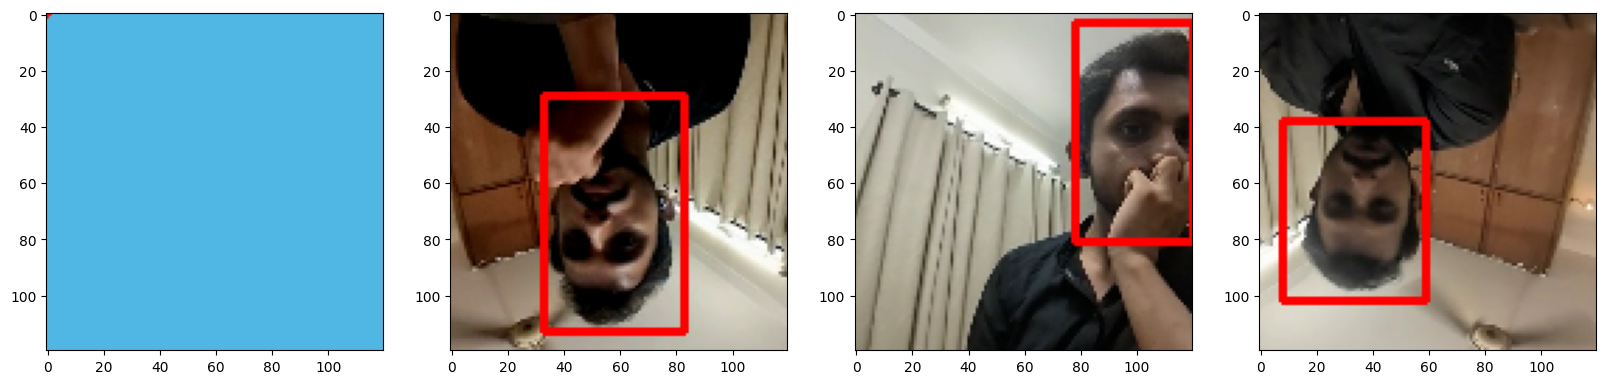

In [77]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = res[0][idx].copy()
    sample_coords = res[1][1][idx]
    
    cv2.rectangle(sample_image, 
                  tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                  tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                        (255,0,0), 2)

    ax[idx].imshow(sample_image)

## 8 Build Deep Learning using the Functional API

### 8.1 Import Layers and Base Network


In [78]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D
from tensorflow.keras.applications import VGG16

### 8.2 Download VGG16

In [79]:
vgg = VGG16(include_top=False)

In [80]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### 8.3 Build instance of Network

In [81]:
def build_model(): 
    input_layer = Input(shape=(120,120,3))
    
    vgg = VGG16(include_top=False)(input_layer)

    # Classification Model  
    f1 = GlobalMaxPooling2D()(vgg)
    class1 = Dense(2048, activation='relu')(f1)
    class2 = Dense(1, activation='sigmoid')(class1)
    
    # Bounding box model
    f2 = GlobalMaxPooling2D()(vgg)
    regress1 = Dense(2048, activation='relu')(f2)
    regress2 = Dense(4, activation='sigmoid')(regress1)
    
    facetracker = Model(inputs=input_layer, outputs=[class2, regress2])
    return facetracker

### 8.4 Test out Neural Network

In [82]:
facetracker = build_model()


In [83]:
facetracker.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2048)      │  1,050,624 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 2048)      │  1,050,624 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      2,049 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │      8,196 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,826,181 (64.19 MB)

 Trainable params: 16,826,181 (64.19 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
X, y = train.as_numpy_iterator().next()


In [85]:
X.shape


(8, 120, 120, 3)

In [86]:
classes, coords = facetracker.predict(X)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


In [87]:
classes, coords

(array([[0.5777799 ],
        [0.48572755],
        [0.518671  ],
        [0.52178544],
        [0.53545487],
        [0.47874263],
        [0.47918573],
        [0.5042961 ]], dtype=float32),
 array([[0.51646316, 0.67787224, 0.25522295, 0.65888655],
        [0.52708864, 0.5741818 , 0.46217263, 0.621006  ],
        [0.5038162 , 0.5059923 , 0.3718517 , 0.6050106 ],
        [0.6105808 , 0.6215327 , 0.3245097 , 0.59071136],
        [0.48608762, 0.6938052 , 0.39140677, 0.68259186],
        [0.5263907 , 0.58317363, 0.460248  , 0.6249757 ],
        [0.5271296 , 0.58348644, 0.46011186, 0.62578166],
        [0.55788183, 0.5818188 , 0.40176335, 0.6098693 ]], dtype=float32))

## 9 Define Losses and Optimizers

### 9.1 Define Optimizer and LR

In [88]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [89]:
lr_decay

0.00044863167339614165

In [90]:
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.0001,
    decay_steps=1,
    decay_rate=lr_decay
)

In [91]:
for step in [0, 1, batches_per_epoch]:
    print(step, lr_schedule(step).numpy())

0 1e-04
1 9.9955156e-05
743 7.4999996e-05


In [92]:
opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
opt

### 9.2 Create Localization Loss and Classification Loss

In [93]:
def localization_loss(y_true, yhat):            
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))
                  
    h_true = y_true[:,3] - y_true[:,1] 
    w_true = y_true[:,2] - y_true[:,0] 

    h_pred = yhat[:,3] - yhat[:,1] 
    w_pred = yhat[:,2] - yhat[:,0] 
    
    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))
    
    return delta_coord + delta_size

In [94]:
classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

### 9.3 Test out Loss Metrics

In [95]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=8.428376197814941>

In [96]:
classloss(y[0], classes)

<tf.Tensor: shape=(), dtype=float32, numpy=0.6417064666748047>

In [97]:
regressloss(y[1], coords)


<tf.Tensor: shape=(), dtype=float32, numpy=8.428376197814941>

## 10 Train Neural Network

### 10.1 Create Custom Model Class

In [98]:
class FaceTracker(Model): 
    def __init__(self, facetracker,  **kwargs): 
        super().__init__(**kwargs)
        self.model = facetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt
    
    def train_step(self, batch, **kwargs): 
        
        X, y = batch
        
        with tf.GradientTape() as tape: 
            classes, coords = self.model(X, training=True)
            
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
            
            total_loss = batch_localizationloss+0.5*batch_classloss
            
            grad = tape.gradient(total_loss, self.model.trainable_variables)
        
        opt.apply_gradients(zip(grad, self.model.trainable_variables))
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
    
    def test_step(self, batch, **kwargs): 
        X, y = batch
        
        classes, coords = self.model(X, training=False)
        
        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
        
    def call(self, X, **kwargs): 
        return self.model(X, **kwargs)

In [99]:
model = FaceTracker(facetracker)

In [100]:
model.compile(opt, classloss, regressloss)

### 10.2 Train

In [101]:
logdir='logs'

In [102]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [103]:
hist = model.fit(train, epochs=10, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 281s 373ms/step - class_loss: 1.0411e-04 - regress_loss: 0.0211 - total_loss: 0.0211 - val_class_loss: 1.4889e-04 - val_regress_loss: 0.0147 - val_total_loss: 0.0148
Epoch 2/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 277s 370ms/step - class_loss: 1.2648e-05 - regress_loss: 0.0108 - total_loss: 0.0108 - val_class_loss: 3.3093e-05 - val_regress_loss: 0.0078 - val_total_loss: 0.0078
Epoch 3/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 279s 372ms/step - class_loss: 2.9216e-05 - regress_loss: 0.0053 - total_loss: 0.0053 - val_class_loss: 1.6716e-04 - val_regress_loss: 0.0018 - val_total_loss: 0.0019
Epoch 4/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 278s 372ms/step - class_loss: 2.5444e-05 - regress_loss: 0.0081 - total_loss: 0.0081 - val_class_loss: 1.2172e-06 - val_regress_loss: 0.0070 - val_total_loss: 0.0070
Epoch 5/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 305s 408ms/step - class_loss: 9.1975e-07 - regress_loss: 0.0021 - total_loss: 0.0021 - val_class_loss: 1.4069e-06 - val_regress_loss: 0.

### 10.3 Plot Performance

In [104]:
hist.history


{'class_loss': [0.00010411231778562069,
  1.2647537005250342e-05,
  2.9216331313364208e-05,
  2.5444462153245695e-05,
  9.197450481224223e-07,
  1.7245664594156551e-06,
  1.1468250704638194e-06,
  5.084798999632767e-07,
  2.8030999033035187e-07,
  5.552489892579615e-05],
 'regress_loss': [0.021090256050229073,
  0.010807042941451073,
  0.005332670174539089,
  0.008089152164757252,
  0.0020972411148250103,
  0.001986568095162511,
  0.0011043113190680742,
  0.0012487790081650019,
  0.002639857353642583,
  0.0011319518089294434],
 'total_loss': [0.02114231139421463,
  0.010813366621732712,
  0.00534727843478322,
  0.0081018740311265,
  0.0020977009553462267,
  0.001987430267035961,
  0.0011048847809433937,
  0.001249033259227872,
  0.0026399975176900625,
  0.0011597143020480871],
 'val_class_loss': [0.0001488900015829131,
  3.309333260403946e-05,
  0.0001671569625614211,
  1.2172159813417238e-06,
  1.4069481721890043e-06,
  9.23982952372171e-05,
  7.120974032659433e-07,
  1.44315231409564

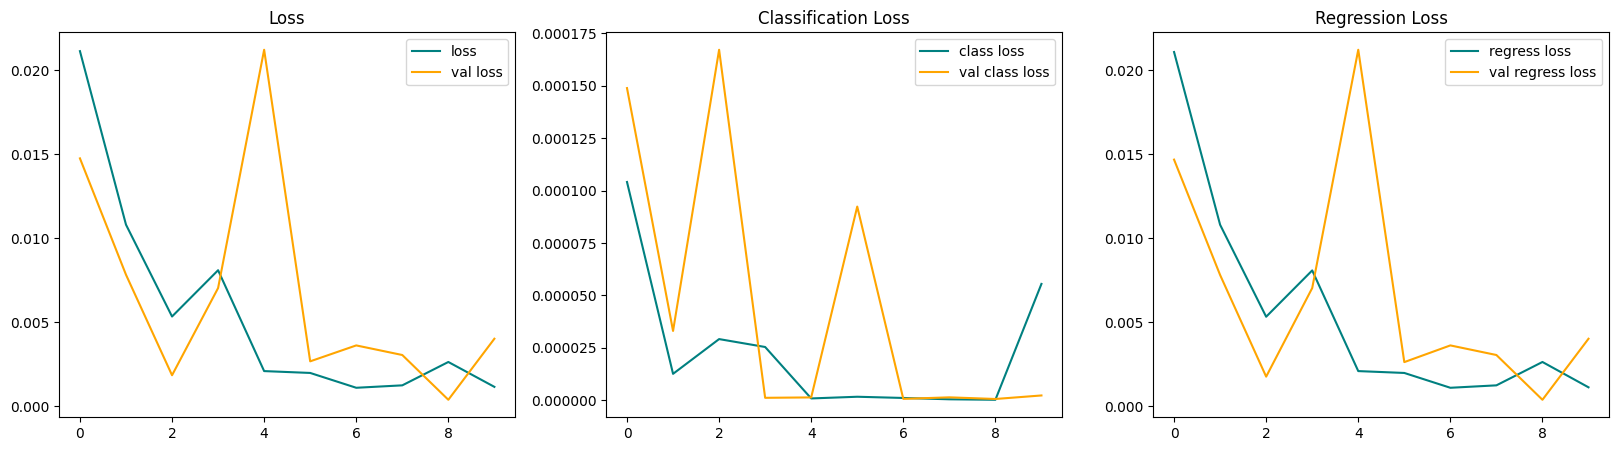

In [105]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

## 11 Make Predictions

### 11.1 Make Predictions on Test Set

In [106]:
test_data = test.as_numpy_iterator()


In [107]:
test_sample = test_data.next()


In [108]:
yhat = facetracker.predict(test_sample[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


In [109]:
print(yhat[0])

[[9.9999982e-01]
 [9.9998337e-01]
 [9.9999899e-01]
 [1.0000000e+00]
 [1.0000000e+00]
 [9.9999726e-01]
 [5.0471403e-08]
 [9.9999398e-01]]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


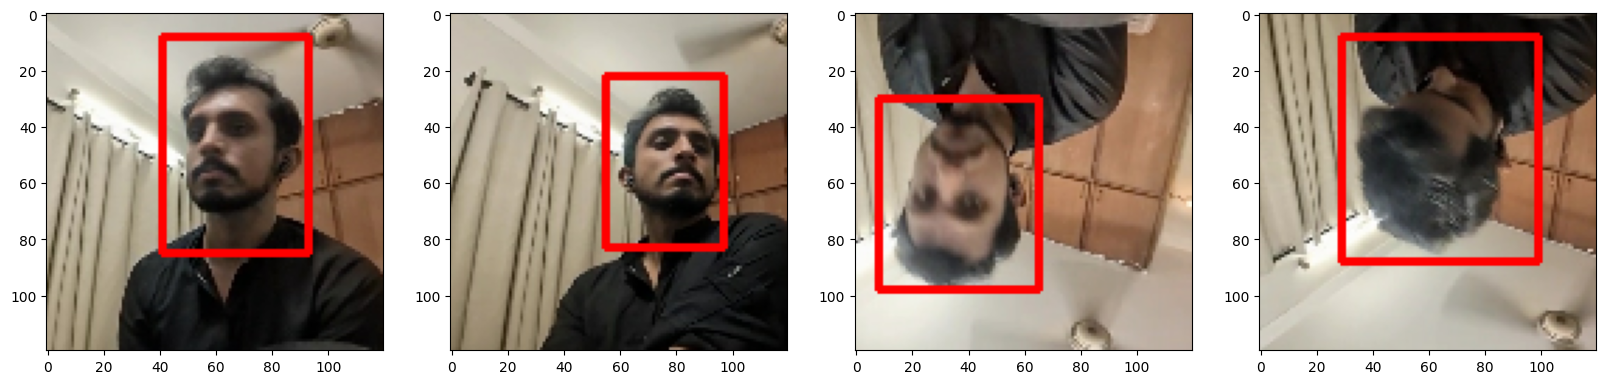

In [110]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = test_sample[0][idx].copy()   # <-- .copy() added
    sample_coords = yhat[1][idx]
    
    if yhat[0][idx] > 0.9:
        cv2.rectangle(sample_image, 
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                            (255,0,0), 2)
    
    ax[idx].imshow(sample_image)

### 11.2 Save the Model

In [111]:
from tensorflow.keras.models import load_model


In [112]:
facetracker.save('facetracker.h5')


In [113]:
facetracker = load_model('facetracker.h5')


### 11.3 Real Time Detection

In [114]:
cap = cv2.VideoCapture(2, cv2.CAP_DSHOW)
while cap.isOpened():
    ret, frame = cap.read()
    
    if not ret or frame is None:
        continue   # skip this iteration, try again
    
    frame = frame[50:500, 50:500, :]
    h, w, _ = frame.shape

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))
    
    yhat = facetracker.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[1][0]
    
    if yhat[0] > 0.5: 
        cv2.rectangle(frame, 
                      tuple(np.multiply(sample_coords[:2], [w,h]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [w,h]).astype(int)), 
                            (255,0,0), 2)
        cv2.rectangle(frame, 
                      tuple(np.add(np.multiply(sample_coords[:2], [w,h]).astype(int), 
                                    [0,-30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [w,h]).astype(int),
                                    [80,0])), 
                            (255,0,0), -1)
        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [w,h]).astype(int),
                                               [0,-5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
    
    cv2.imshow('facetracker', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━

KeyboardInterrupt: 